# Univariate and Multivariate Analysis
### Dataset: Seaborn `diamonds` dataset

This notebook performs univariate analysis on the **carat** variable and multivariate analysis examining the relationship between **carat**, **price**, and **cut**.

## 1. Import seaborn and load the diamonds dataset

In [1]:
# Grabbing seaborn since it already has the diamonds dataset built in
import seaborn as sns

# Loading up the diamonds dataset
diamonds = sns.load_dataset("diamonds")

# Just peeking at the first few rows to make sure everything loaded fine
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 2. Import relevant libraries for statistical analysis

In [2]:
# numpy for crunching numbers like mean, std, correlation, etc.
import numpy as np

# pandas for working with the data table itself
import pandas as pd

# matplotlib and seaborn for making the charts
import matplotlib.pyplot as plt

# scipy has some handy extra stats like skewness
from scipy import stats

# Quick check of the data types and summary stats before getting into it
diamonds.info()
diamonds.describe()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## 3. Univariate Analysis

**Variable chosen: `carat`**

I went with `carat` (basically how much the diamond weighs) because it's a nice continuous number and it plays a huge role in how diamonds are priced. Figured it'd be interesting to see its distribution on its own before comparing it to anything else.

In [3]:
# --- Univariate Analysis on 'carat' ---

# Pulling some basic stats to get a feel for the carat column
carat_mean = np.mean(diamonds['carat'])
carat_median = np.median(diamonds['carat'])
carat_std = np.std(diamonds['carat'])
carat_min = np.min(diamonds['carat'])
carat_max = np.max(diamonds['carat'])
carat_skew = stats.skew(diamonds['carat'])

print(f"Mean carat:     {carat_mean:.3f}")
print(f"Median carat:   {carat_median:.3f}")
print(f"Std Dev carat:  {carat_std:.3f}")
print(f"Min carat:      {carat_min:.3f}")
print(f"Max carat:      {carat_max:.3f}")
print(f"Skewness:       {carat_skew:.3f}")  # positive number means it's skewed right, so a few big diamonds are dragging the tail out

Mean carat:     0.798
Median carat:   0.700
Std Dev carat:  0.474
Min carat:      0.200
Max carat:      5.010
Skewness:       1.117


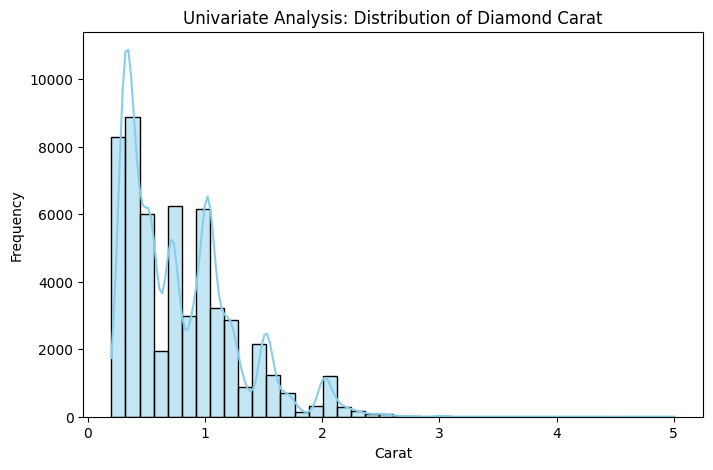

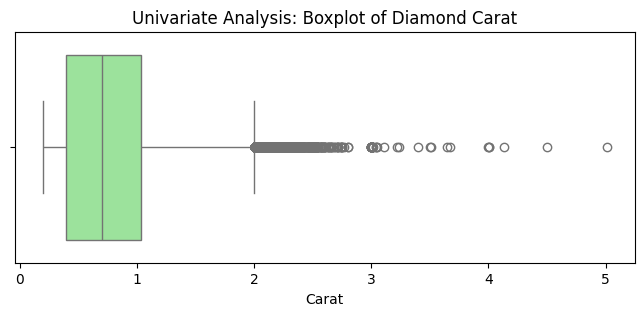

In [4]:
# Let's actually look at the shape of the data with a histogram + KDE line
plt.figure(figsize=(8, 5))
sns.histplot(diamonds['carat'], kde=True, bins=40, color='skyblue')
plt.title('Univariate Analysis: Distribution of Diamond Carat')
plt.xlabel('Carat')
plt.ylabel('Frequency')
plt.show()

# And a boxplot to spot the spread and any outliers
plt.figure(figsize=(8, 3))
sns.boxplot(x=diamonds['carat'], color='lightgreen')
plt.title('Univariate Analysis: Boxplot of Diamond Carat')
plt.xlabel('Carat')
plt.show()

# So what are we seeing here:
# Most diamonds are on the smaller side (under about 1 carat), and then
# there's a long tail of bigger, rarer ones pulling the distribution to
# the right. The boxplot backs this up too, showing a bunch of outliers
# on the higher end.

## 4. Multivariate Analysis

**Variables chosen: `carat`, `price`, and `cut`**

For this part I wanted to bring in `carat`, `price`, and `cut` together, since that's where things get more interesting — do bigger diamonds really cost more, and does the quality of the cut change that story at all?

In [5]:
# --- Multivariate Analysis: carat, price, and cut ---

# How closely are carat and price related?
correlation = np.corrcoef(diamonds['carat'], diamonds['price'])[0, 1]
print(f"Correlation between carat and price: {correlation:.3f}")

# Breaking things down by cut to compare average carat and price per group
summary_by_cut = diamonds.groupby('cut', observed=True)[['carat', 'price']].mean()
print("\nAverage carat and price by cut quality:")
print(summary_by_cut)

Correlation between carat and price: 0.922

Average carat and price by cut quality:
              carat        price
cut                             
Ideal      0.702837  3457.541970
Premium    0.891955  4584.257704
Very Good  0.806381  3981.759891
Good       0.849185  3928.864452
Fair       1.046137  4358.757764


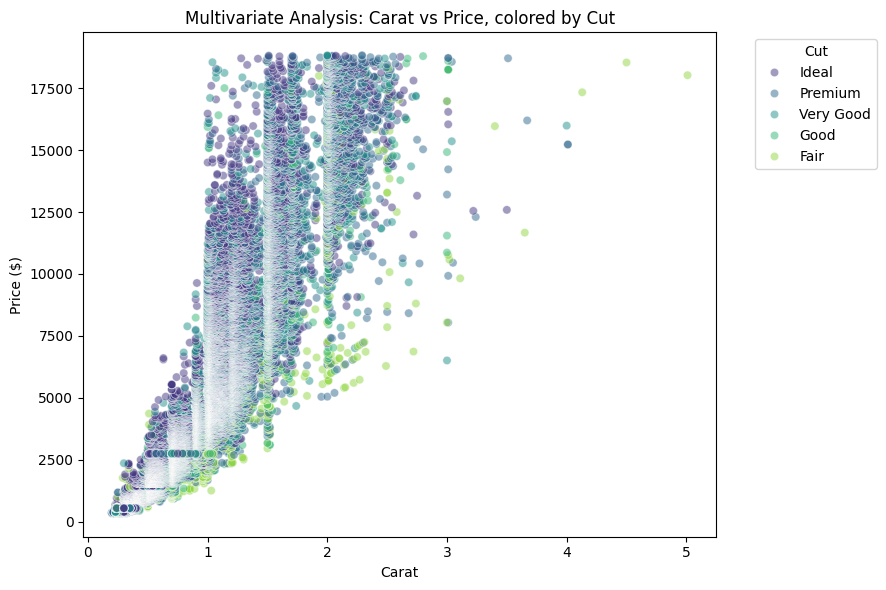

In [6]:
# Plotting carat vs price, with cut shown by color, so we can see all
# three things at once
plt.figure(figsize=(9, 6))
sns.scatterplot(data=diamonds, x='carat', y='price', hue='cut', alpha=0.5, palette='viridis')
plt.title('Multivariate Analysis: Carat vs Price, colored by Cut')
plt.xlabel('Carat')
plt.ylabel('Price ($)')
plt.legend(title='Cut', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Takeaways:
# Yep, carat and price are strongly linked — heavier diamonds cost more,
# and it looks like the price climbs faster than carat weight does (more
# of a curve than a straight line). Once we add cut into the mix, you can
# see that for the same carat weight, diamonds with better cuts (like
# 'Ideal' or 'Premium') tend to sell for more, so cut is clearly adding
# its own effect on top of size.

## Summary

- **Univariate Analysis**: looked at `carat` on its own and found the distribution is right-skewed — most diamonds are small, with a handful of bigger ones stretching the tail out.
- **Multivariate Analysis**: looked at `carat`, `price`, and `cut` together and found a strong positive relationship between carat and price, with cut quality adding an extra boost to price on top of that.